# Indian Startup Funding — EDA & Hypothesis Testing

**Notebook 04 of 4** | Goal: Visualize key patterns and test 5 ecosystem narratives against data.

## Structure
- **Part 1:** Exploratory Data Analysis — 14 charts across 7 sections
- **Part 2:** Hypothesis Testing — 5 narratives tested with verdicts

## Data Source
Clean master dataset: `data/processed/funding_clean.csv`
All analysis uses data from 2014–2019 unless stated otherwise.

In [2]:
# ─── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ─── Style configuration ──────────────────────────────────
plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.labelsize']    = 11

# ─── Color palette ────────────────────────────────────────
COLORS = {
    'primary':   '#2563EB',
    'secondary': '#F59E0B',
    'positive':  '#10B981',
    'negative':  '#EF4444',
    'neutral':   '#6B7280',
    'highlight': '#7C3AED'
}

SECTOR_COLORS = [
    '#2563EB', '#F59E0B', '#10B981', '#EF4444',
    '#7C3AED', '#EC4899', '#06B6D4', '#84CC16',
    '#F97316', '#6366F1', '#14B8A6', '#F43F5E',
    '#8B5CF6'
]

# ─── Load data ────────────────────────────────────────────
df = pd.read_csv('../data/processed/funding_clean.csv')
conn = sqlite3.connect('../data/processed/funding.db')

print(f"Dataset loaded: {df.shape}")
print(f"Database connected")
print(f"\nYear range: {int(df['year'].min())} - {int(df['year'].max())}")
print(f"Total rows: {len(df):,}")

Dataset loaded: (3998, 16)
Database connected

Year range: 1999 - 2020
Total rows: 3,998


---

## Part 1: Exploratory Data Analysis

### Section 1 — Yearly Funding Trends

How did total capital deployed and deal count evolve from 2014 to 2019?

In [4]:
import os

# Create figures directory if it doesn't exist
os.makedirs('../reports/figures', exist_ok=True)
print("figures folder ready")

figures folder ready


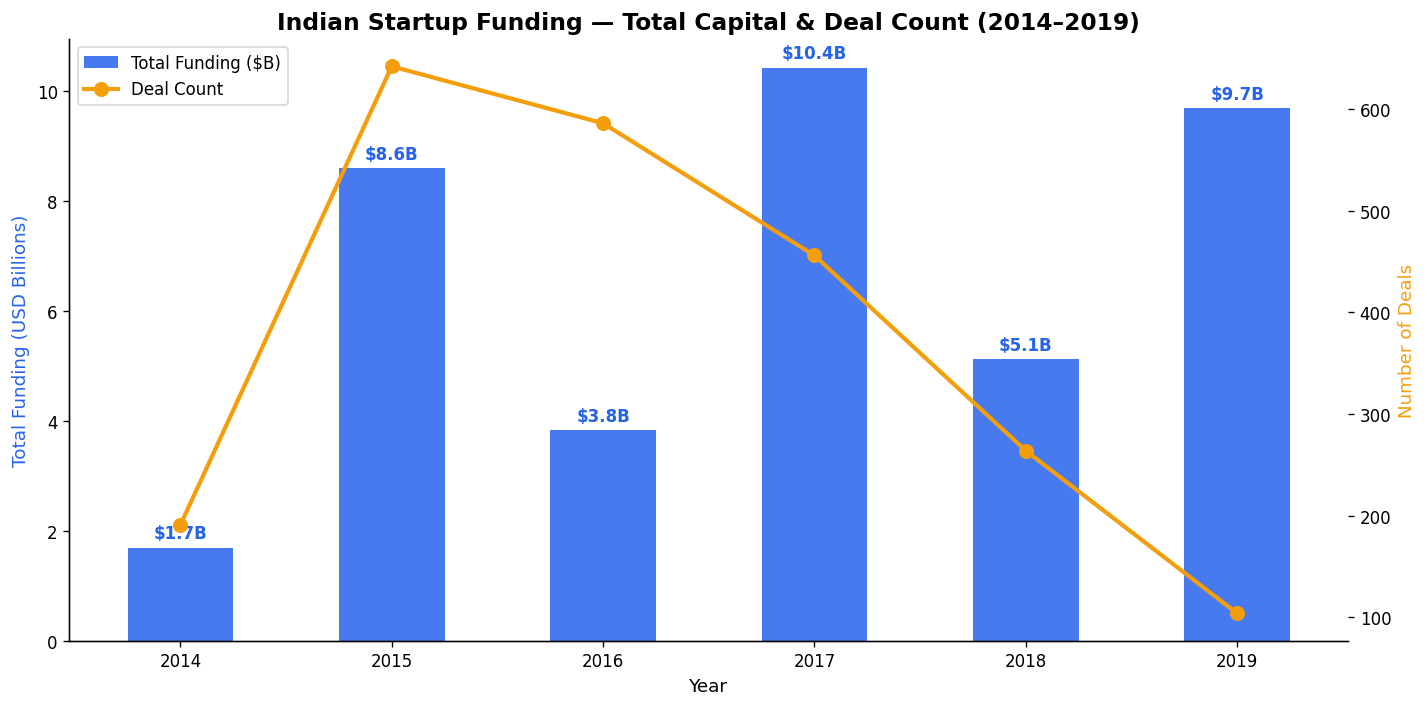

✓ Chart 1 saved


In [5]:
# ─── Chart 1: Total Funding By Year ───────────────────────

yearly = pd.read_sql("""
    SELECT
        CAST(year AS INTEGER) AS year,
        COUNT(*) AS deals,
        ROUND(SUM(amount_usd)/1e9, 2) AS funding_bn_usd
    FROM funding_rounds
    WHERE year >= 2014 AND year <= 2019
      AND amount_usd IS NOT NULL
    GROUP BY year
    ORDER BY year
""", conn)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for funding
bars = ax1.bar(
    yearly['year'],
    yearly['funding_bn_usd'],
    color=COLORS['primary'],
    alpha=0.85,
    width=0.5,
    label='Total Funding ($B)'
)

# Add value labels on bars
for bar, val in zip(bars, yearly['funding_bn_usd']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'${val:.1f}B',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color=COLORS['primary']
    )

# Second axis for deal count
ax2 = ax1.twinx()
ax2.plot(
    yearly['year'],
    yearly['deals'],
    color=COLORS['secondary'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Deal Count'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Funding (USD Billions)', color=COLORS['primary'])
ax2.set_ylabel('Number of Deals', color=COLORS['secondary'])
ax1.set_title('Indian Startup Funding — Total Capital & Deal Count (2014–2019)')
ax1.set_xticks(yearly['year'])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/chart_01_yearly_funding.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved")

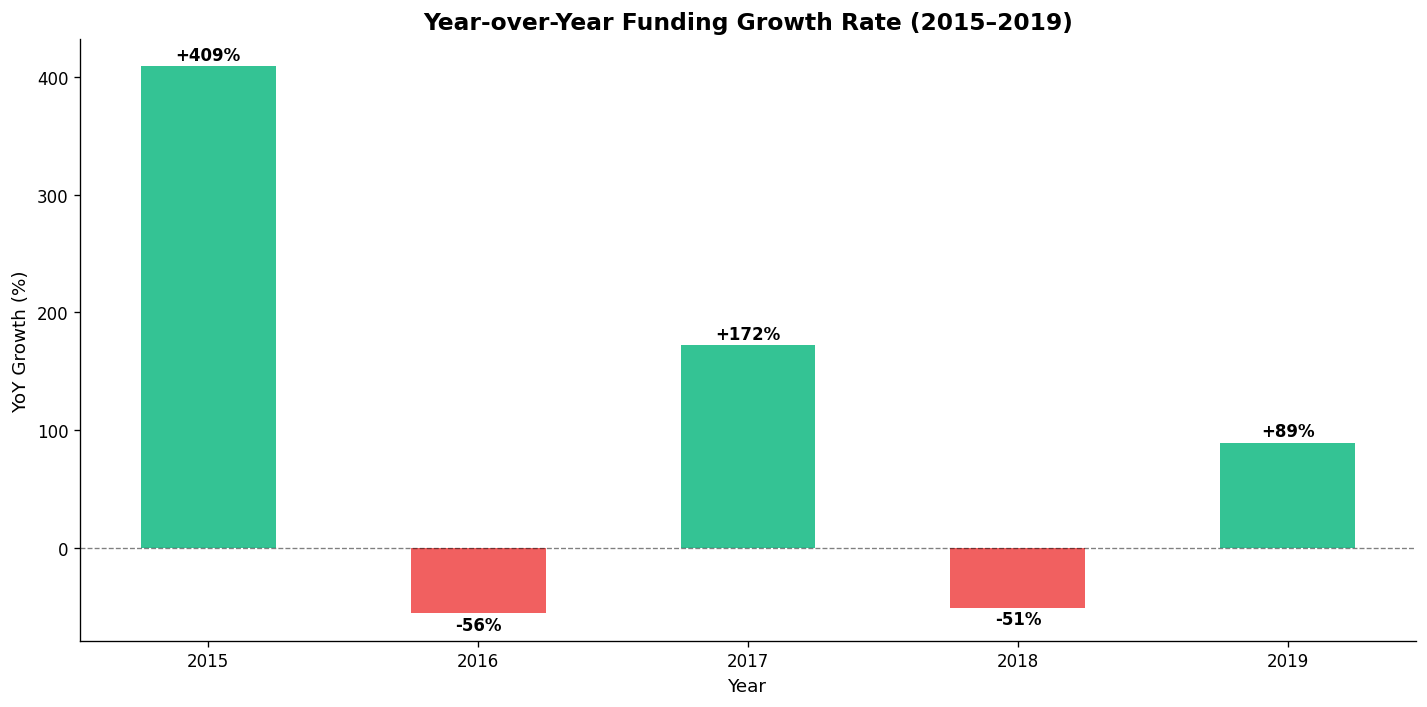

Chart 2 saved


In [6]:
# Chart 2: Year-over-Year Growth Rate

yoy = pd.read_sql("""
    WITH yearly AS (
        SELECT
            CAST(year AS INTEGER) AS year,
            ROUND(SUM(amount_usd)/1e9, 2) AS funding_bn
        FROM funding_rounds
        WHERE year >= 2014 AND year <= 2019
          AND amount_usd IS NOT NULL
        GROUP BY year
    )
    SELECT
        year,
        funding_bn,
        ROUND(
            (funding_bn - LAG(funding_bn,1) OVER (ORDER BY year)) * 100.0 /
            LAG(funding_bn,1) OVER (ORDER BY year)
        , 1) AS yoy_growth
    FROM yearly
""", conn).dropna()

colors = [COLORS['positive'] if x >= 0 else COLORS['negative']
          for x in yoy['yoy_growth']]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(yoy['year'], yoy['yoy_growth'],
              color=colors, width=0.5, alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for bar, val in zip(bars, yoy['yoy_growth']):
    va = 'bottom' if val >= 0 else 'top'
    offset = 2 if val >= 0 else -2
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:+.0f}%',
            ha='center', va=va,
            fontsize=10, fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('YoY Growth (%)')
ax.set_title('Year-over-Year Funding Growth Rate (2015–2019)')
ax.set_xticks(yoy['year'])

plt.tight_layout()
plt.savefig('../reports/figures/chart_02_yoy_growth.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

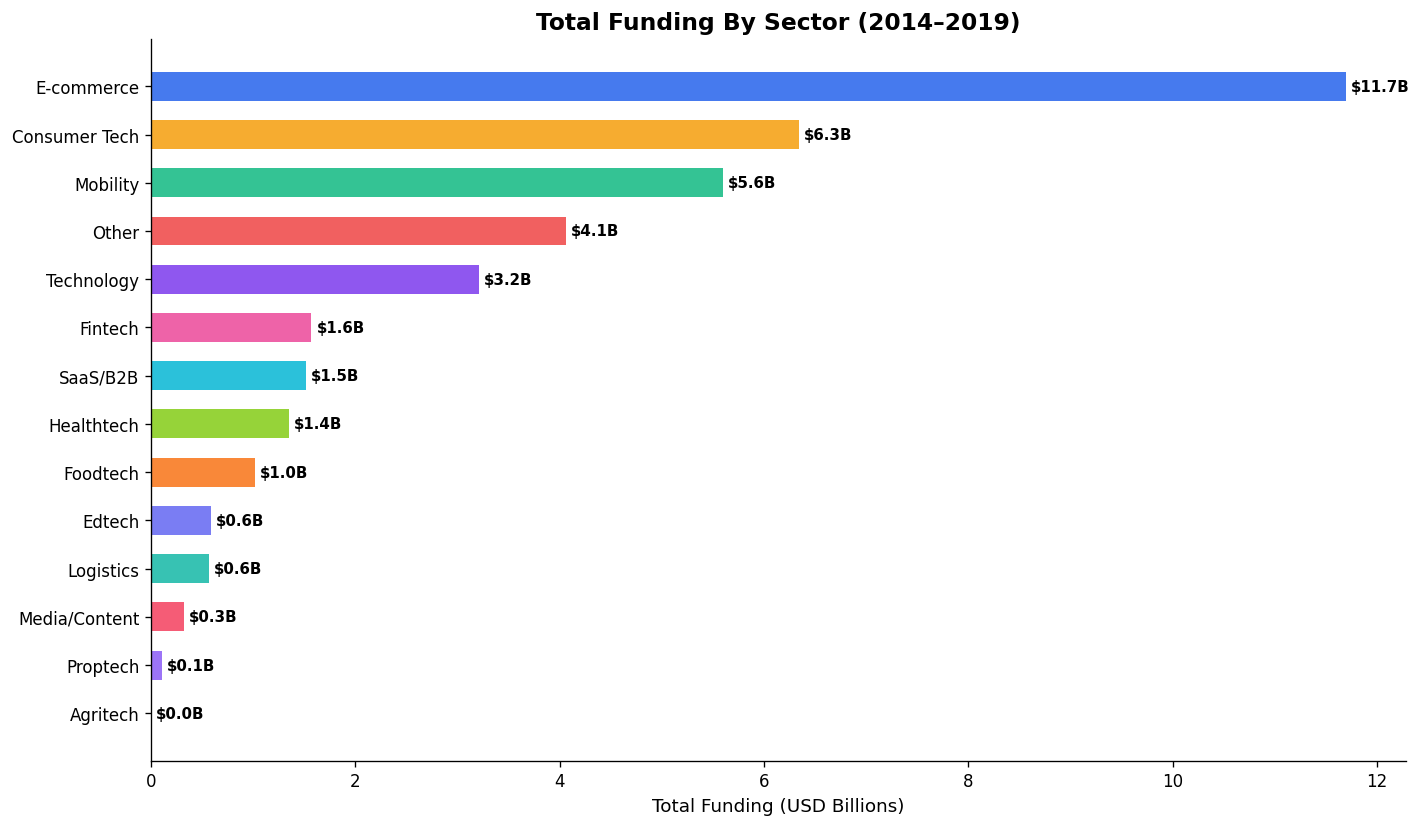

Chart 3 saved


In [7]:
# Chart 3: Total Funding By Sector

sector_funding = pd.read_sql("""
    SELECT
        sector,
        COUNT(*) AS deals,
        ROUND(SUM(amount_usd)/1e9, 2) AS funding_bn_usd
    FROM funding_rounds
    WHERE year >= 2014 AND year <= 2019
      AND sector IS NOT NULL
      AND amount_usd IS NOT NULL
    GROUP BY sector
    ORDER BY funding_bn_usd DESC
""", conn)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    sector_funding['sector'],
    sector_funding['funding_bn_usd'],
    color=SECTOR_COLORS[:len(sector_funding)],
    alpha=0.85,
    height=0.6
)

for bar, val in zip(bars, sector_funding['funding_bn_usd']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'${val:.1f}B',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Funding (USD Billions)')
ax.set_title('Total Funding By Sector (2014–2019)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/chart_03_sector_funding.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

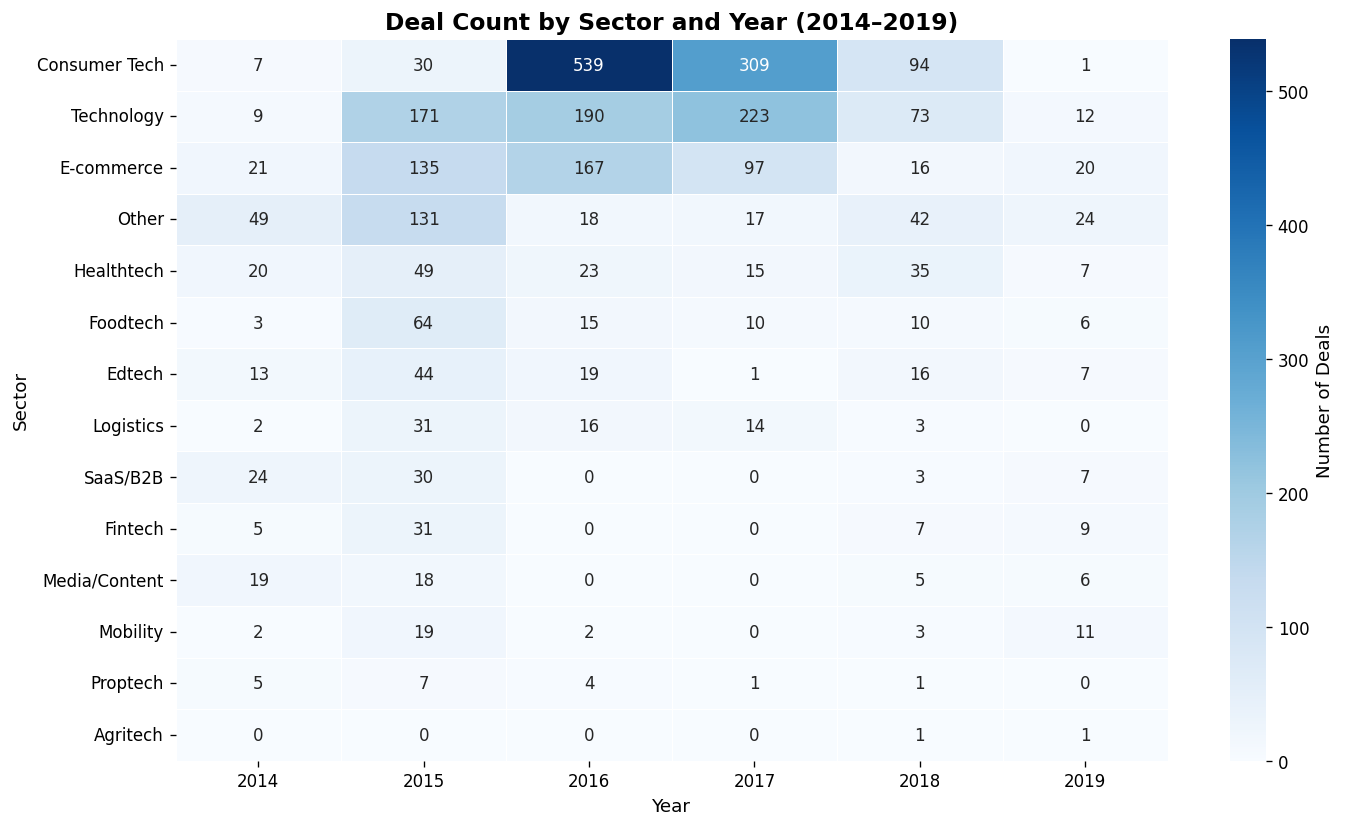

Chart 4 saved


In [8]:
# Chart 4: Sector vs Year Heatmap

heatmap_data = pd.read_sql("""
    SELECT
        CAST(year AS INTEGER) AS year,
        sector,
        COUNT(*) AS deals
    FROM funding_rounds
    WHERE year >= 2014 AND year <= 2019
      AND sector IS NOT NULL
    GROUP BY year, sector
""", conn)

heatmap_pivot = heatmap_data.pivot(
    index='sector',
    columns='year',
    values='deals'
).fillna(0).astype(int)

# Sort by total deals
heatmap_pivot = heatmap_pivot.loc[
    heatmap_pivot.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Number of Deals'}
)

ax.set_title('Deal Count by Sector and Year (2014–2019)')
ax.set_xlabel('Year')
ax.set_ylabel('Sector')

plt.tight_layout()
plt.savefig('../reports/figures/chart_04_sector_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

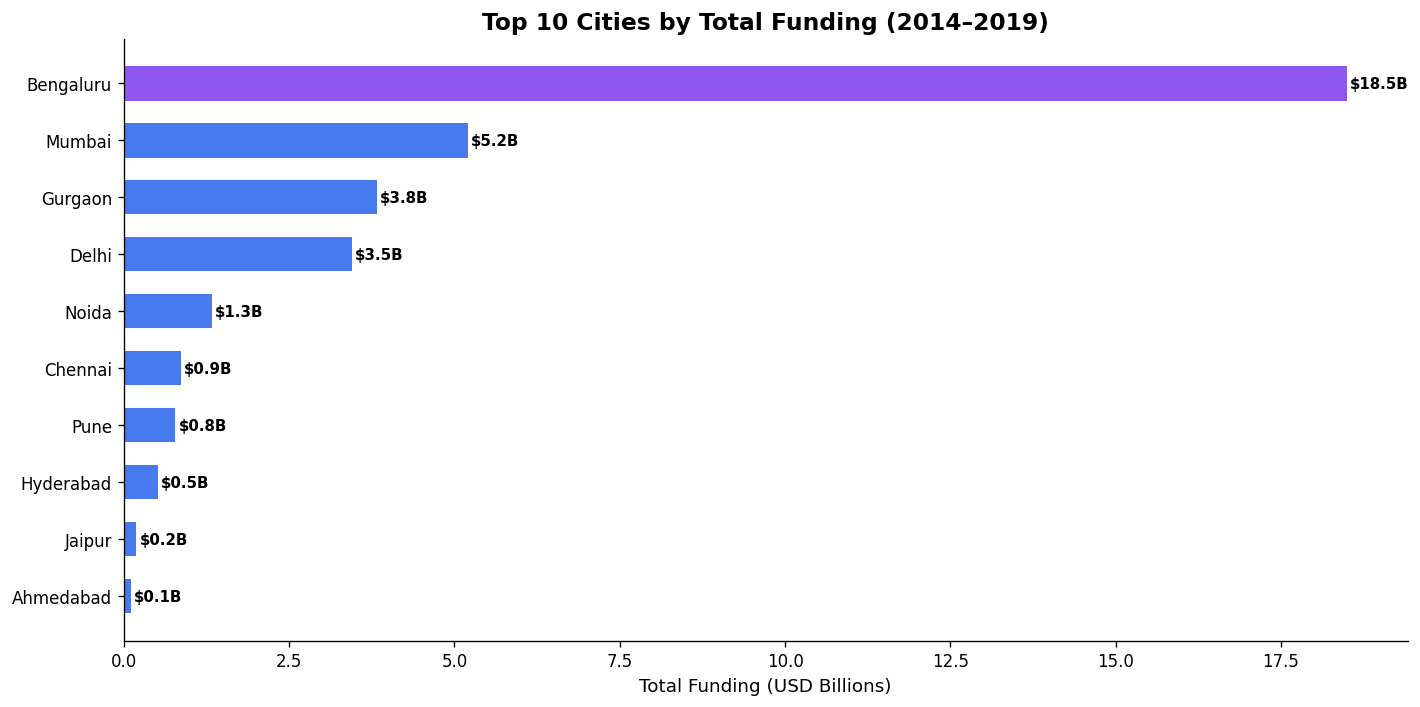

Chart 5 saved


In [9]:
# Chart 5: Top 10 Cities By Funding

cities = pd.read_sql("""
    SELECT
        city_clean AS city,
        COUNT(*) AS deals,
        ROUND(SUM(amount_usd)/1e9, 2) AS funding_bn_usd
    FROM funding_rounds
    WHERE year >= 2014 AND year <= 2019
      AND city_clean IS NOT NULL
      AND amount_usd IS NOT NULL
    GROUP BY city_clean
    HAVING COUNT(*) >= 10
    ORDER BY funding_bn_usd DESC
    LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))

bar_colors = [COLORS['highlight'] if city == 'Bengaluru'
              else COLORS['primary'] for city in cities['city']]

bars = ax.barh(cities['city'], cities['funding_bn_usd'],
               color=bar_colors, alpha=0.85, height=0.6)

for bar, val in zip(bars, cities['funding_bn_usd']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'${val:.1f}B',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Funding (USD Billions)')
ax.set_title('Top 10 Cities by Total Funding (2014–2019)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/chart_05_top_cities.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

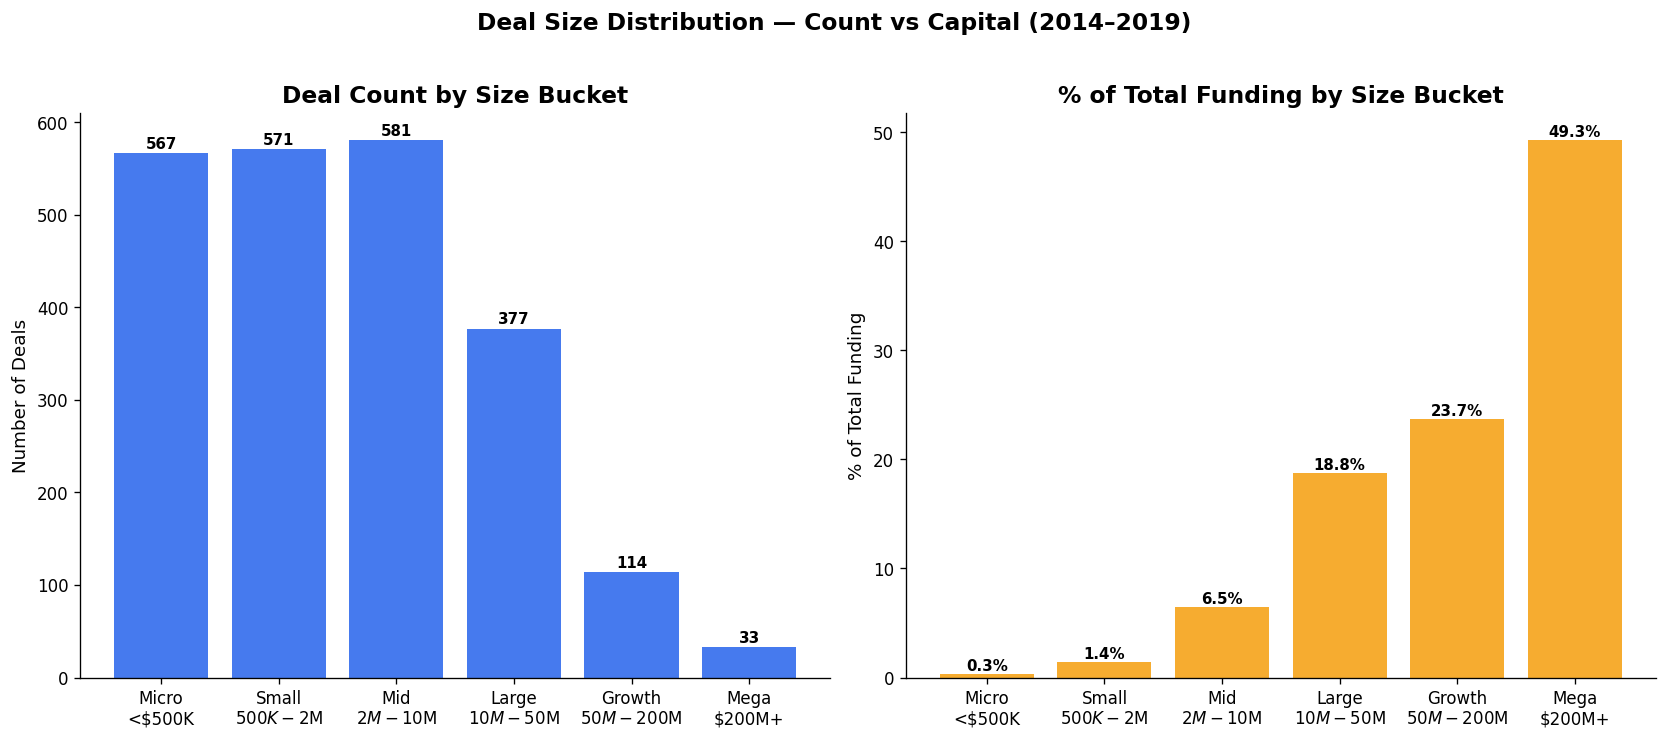

Chart 6 saved


In [10]:
# Chart 6: Deal Size Bucket Distribution

buckets = pd.read_sql("""
    SELECT
        CASE
            WHEN amount_usd < 500000    THEN '1. Micro'
            WHEN amount_usd < 2000000   THEN '2. Small'
            WHEN amount_usd < 10000000  THEN '3. Mid'
            WHEN amount_usd < 50000000  THEN '4. Large'
            WHEN amount_usd < 200000000 THEN '5. Growth'
            ELSE                             '6. Mega'
        END AS bucket,
        COUNT(*) AS deals,
        ROUND(SUM(amount_usd)*100.0/
            SUM(SUM(amount_usd)) OVER(), 1) AS pct_funding
    FROM funding_rounds
    WHERE year >= 2014 AND year <= 2019
      AND amount_usd IS NOT NULL
    GROUP BY bucket
    ORDER BY bucket
""", conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Micro\n<$500K', 'Small\n$500K-$2M',
          'Mid\n$2M-$10M', 'Large\n$10M-$50M',
          'Growth\n$50M-$200M', 'Mega\n$200M+']

ax1.bar(labels, buckets['deals'],
        color=COLORS['primary'], alpha=0.85)
ax1.set_title('Deal Count by Size Bucket')
ax1.set_ylabel('Number of Deals')
for i, val in enumerate(buckets['deals']):
    ax1.text(i, val + 5, str(val),
             ha='center', fontsize=9, fontweight='bold')

ax2.bar(labels, buckets['pct_funding'],
        color=COLORS['secondary'], alpha=0.85)
ax2.set_title('% of Total Funding by Size Bucket')
ax2.set_ylabel('% of Total Funding')
for i, val in enumerate(buckets['pct_funding']):
    ax2.text(i, val + 0.3, f'{val}%',
             ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Deal Size Distribution — Count vs Capital (2014–2019)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/chart_06_deal_size.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

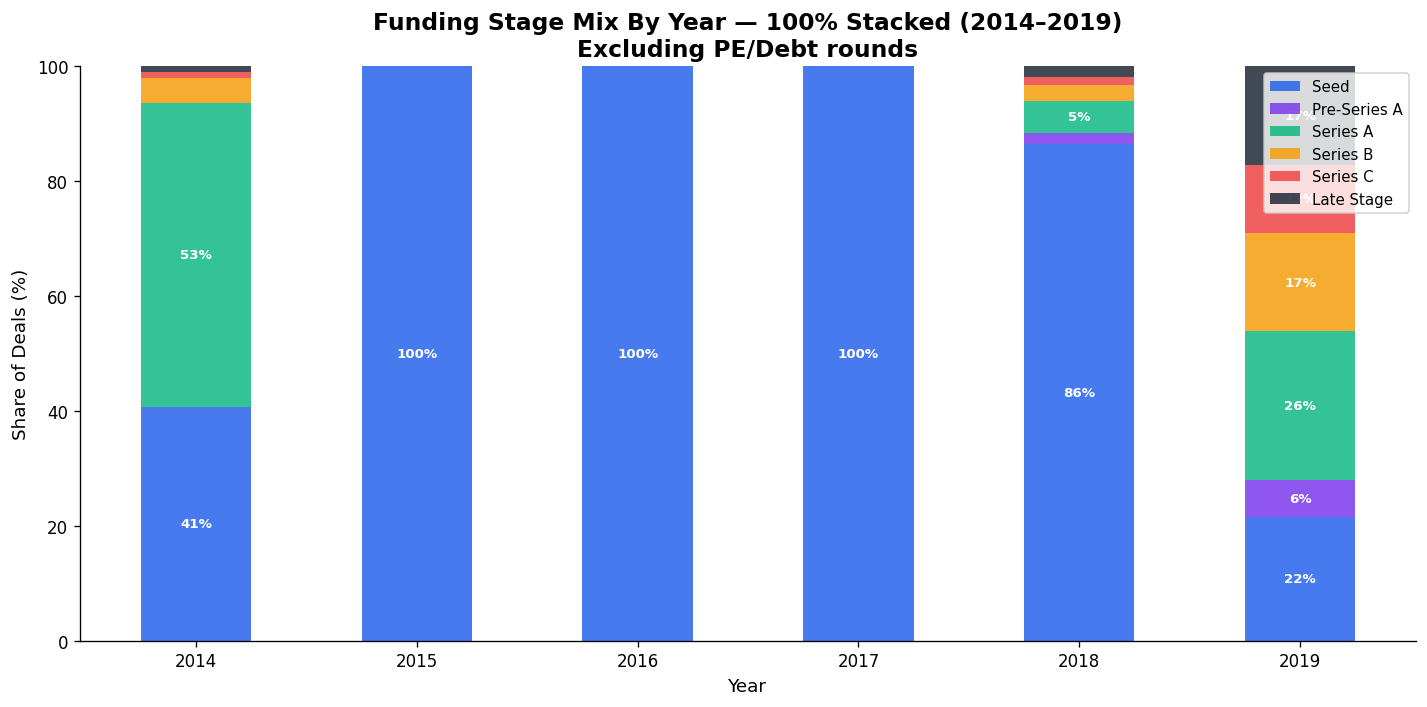

Chart 7 saved


In [14]:
# Chart 7: Stage Mix By Year (100% stacked)

stage_data = pd.read_sql("""
    SELECT
        CAST(year AS INTEGER) AS year,
        stage_clean,
        COUNT(*) AS deals
    FROM funding_rounds
    WHERE year >= 2014 AND year <= 2019
      AND stage_clean IS NOT NULL
      AND stage_clean NOT IN ('Other', 'PE/Debt')
    GROUP BY year, stage_clean
""", conn)

stage_pivot = stage_data.pivot(
    index='year', columns='stage_clean', values='deals'
).fillna(0)

stage_order = ['Seed', 'Pre-Series A', 'Series A',
               'Series B', 'Series C', 'Late Stage']
stage_pivot = stage_pivot.reindex(
    columns=[c for c in stage_order if c in stage_pivot.columns]
)

# Convert to percentages
stage_pct = stage_pivot.div(stage_pivot.sum(axis=1), axis=0) * 100

stage_colors = ['#2563EB', '#7C3AED', '#10B981',
                '#F59E0B', '#EF4444', '#1F2937']

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(stage_pct))
for i, col in enumerate(stage_pct.columns):
    bars = ax.bar(stage_pct.index, stage_pct[col],
                  bottom=bottom,
                  label=col,
                  color=stage_colors[i % len(stage_colors)],
                  alpha=0.85,
                  width=0.5)
    # Add label if segment is wide enough
    for j, (bar, val) in enumerate(zip(bars, stage_pct[col])):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottom[j] + val/2,
                    f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += stage_pct[col].values

ax.set_xlabel('Year')
ax.set_ylabel('Share of Deals (%)')
ax.set_title('Funding Stage Mix By Year — 100% Stacked (2014–2019)\nExcluding PE/Debt rounds')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(stage_pct.index)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../reports/figures/chart_07_stage_evolution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

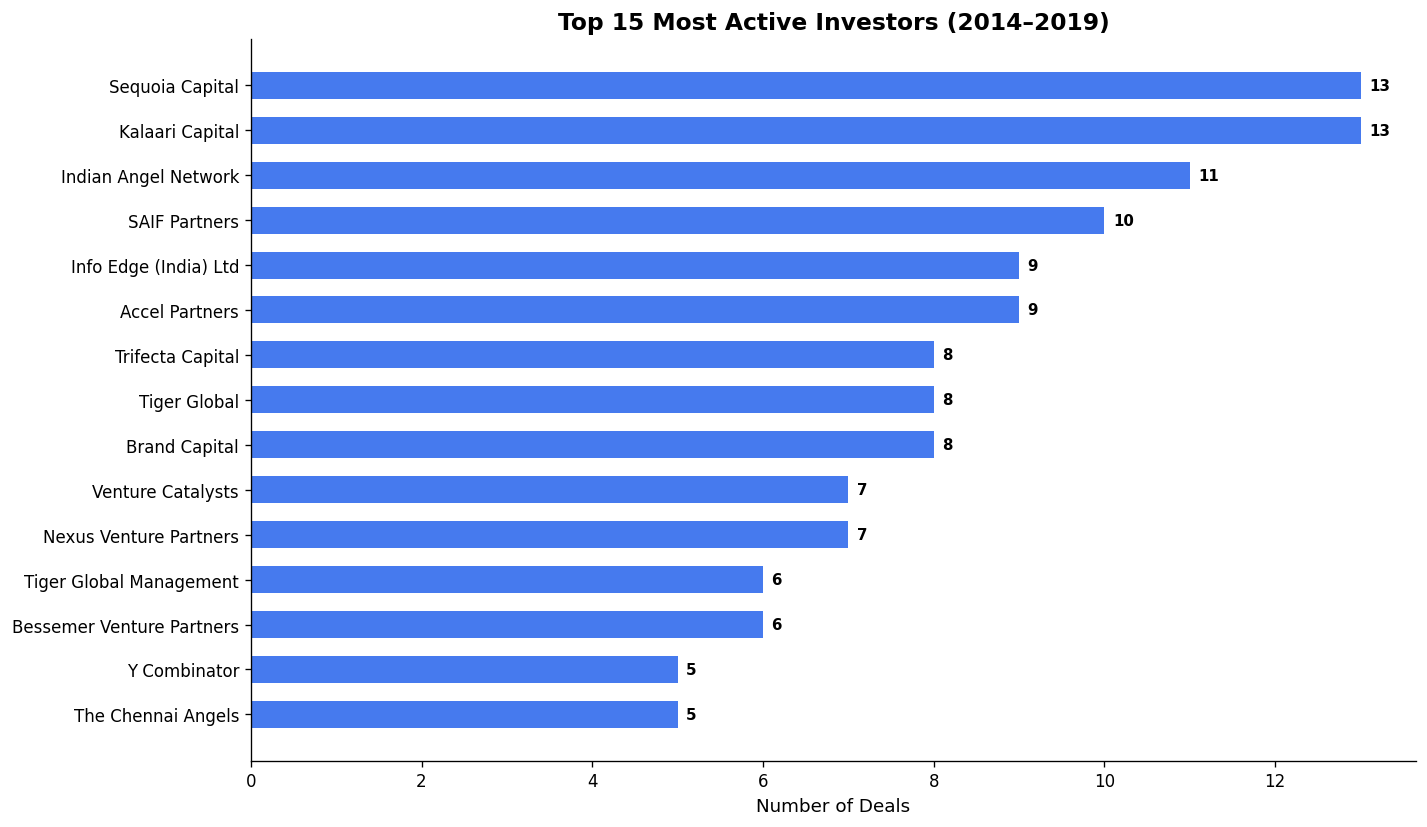

Chart 8 saved


In [13]:
# Chart 8: Top 15 Investors By Deal Count

investors = pd.read_sql("""
    SELECT
        investors,
        COUNT(*) AS total_deals,
        ROUND(SUM(amount_usd)/1e6, 1) AS total_invested_mn
    FROM funding_rounds
    WHERE investors IS NOT NULL
      AND investors != 'nan'
      AND amount_usd IS NOT NULL
      AND year >= 2014 AND year <= 2019
      AND LOWER(investors) NOT LIKE '%undisclosed%'
      AND LOWER(investors) NOT LIKE '%angel investor%'
      AND LOWER(investors) NOT LIKE '%group of%'
    GROUP BY investors
    HAVING COUNT(*) >= 3
    ORDER BY total_deals DESC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(investors['investors'],
               investors['total_deals'],
               color=COLORS['primary'],
               alpha=0.85, height=0.6)

for bar, val in zip(bars, investors['total_deals']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            str(val),
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Number of Deals')
ax.set_title('Top 15 Most Active Investors (2014–2019)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/chart_08_top_investors.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

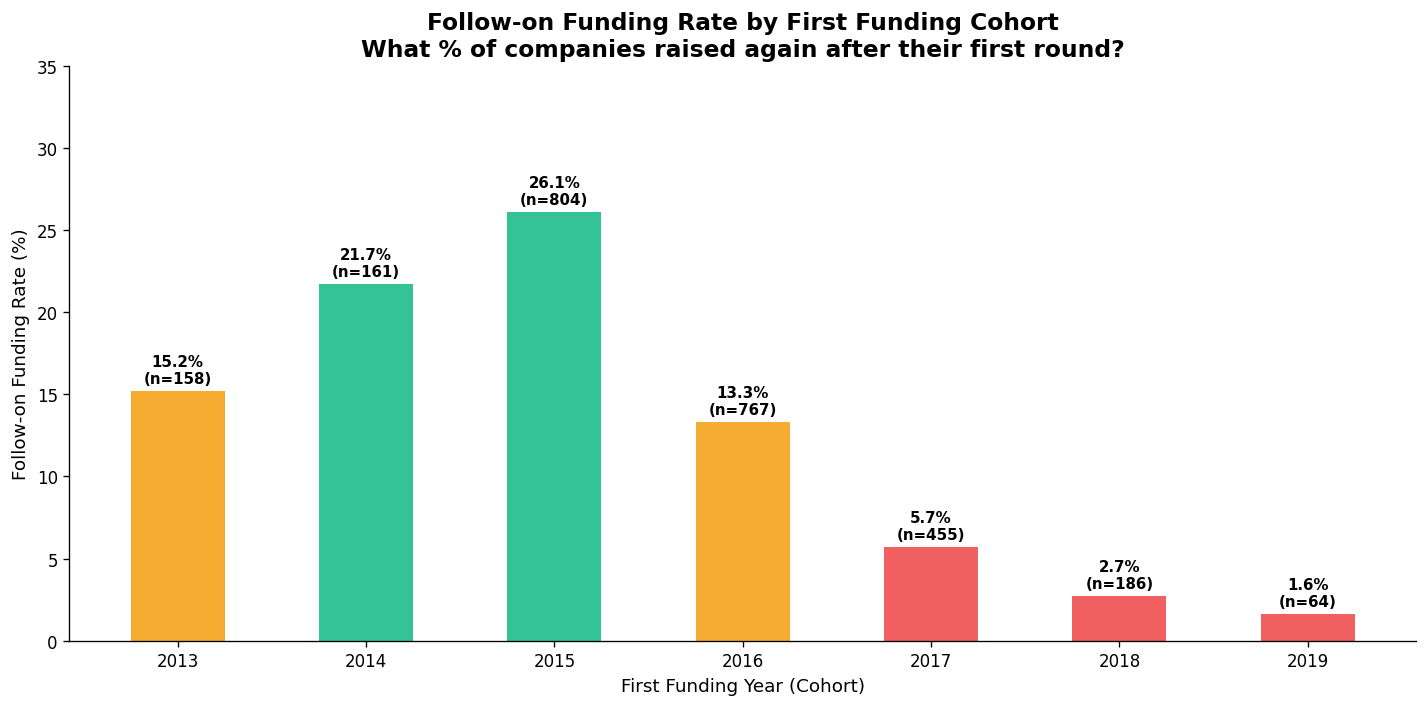

Chart 9 saved


In [15]:
# Chart 9: Cohort Follow-On Rate

cohort = pd.read_sql("""
    WITH first_funding AS (
        SELECT
            startup_name_clean,
            CAST(MIN(year) AS INTEGER) AS cohort_year
        FROM funding_rounds
        WHERE year >= 2013 AND year <= 2019
          AND startup_name_clean IS NOT NULL
        GROUP BY startup_name_clean
    ),
    cohort_activity AS (
        SELECT
            f.cohort_year,
            COUNT(DISTINCT f.startup_name_clean) AS cohort_size,
            COUNT(DISTINCT CASE
                WHEN CAST(r.year AS INTEGER) > f.cohort_year
                THEN f.startup_name_clean
            END) AS raised_followon
        FROM first_funding f
        LEFT JOIN funding_rounds r
            ON f.startup_name_clean = r.startup_name_clean
        GROUP BY f.cohort_year
    )
    SELECT
        cohort_year,
        cohort_size,
        raised_followon,
        ROUND(raised_followon * 100.0 / cohort_size, 1) AS followon_rate
    FROM cohort_activity
    ORDER BY cohort_year
""", conn)

fig, ax1 = plt.subplots(figsize=(12, 6))

bar_colors = [COLORS['positive'] if r >= 20
              else COLORS['negative'] if r < 10
              else COLORS['secondary']
              for r in cohort['followon_rate']]

bars = ax1.bar(cohort['cohort_year'],
               cohort['followon_rate'],
               color=bar_colors, alpha=0.85, width=0.5)

for bar, rate, size in zip(bars, cohort['followon_rate'],
                            cohort['cohort_size']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate}%\n(n={size})',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_xlabel('First Funding Year (Cohort)')
ax1.set_ylabel('Follow-on Funding Rate (%)')
ax1.set_title('Follow-on Funding Rate by First Funding Cohort\nWhat % of companies raised again after their first round?')
ax1.set_xticks(cohort['cohort_year'])
ax1.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('../reports/figures/chart_09_cohort_followon.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved")

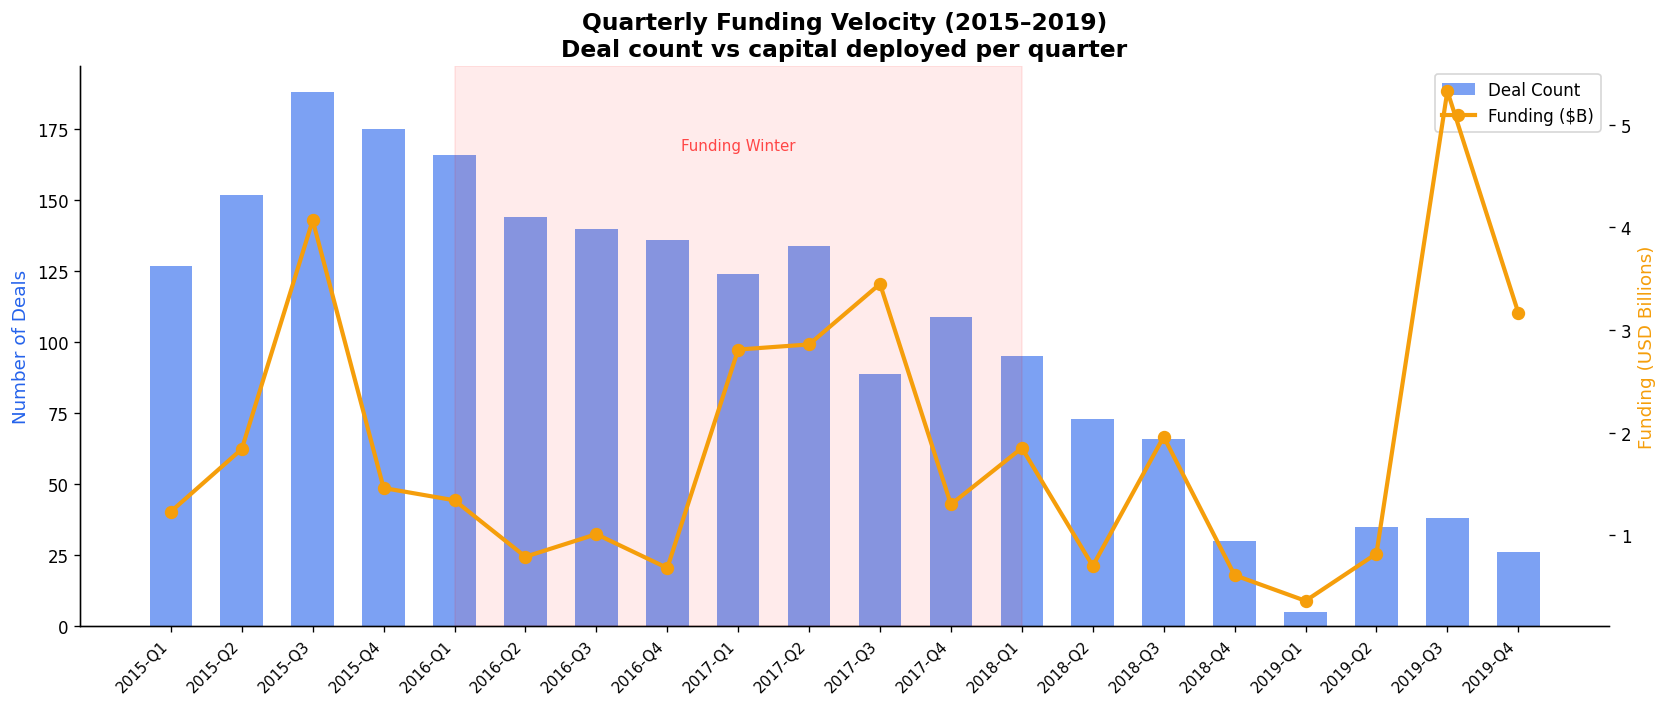

Chart 10 saved


In [16]:
# Chart 10: Quarterly Funding Velocity

quarterly = pd.read_sql("""
    SELECT
        CAST(year AS INTEGER) || '-Q' ||
        CAST(quarter AS INTEGER) AS period,
        CAST(year AS INTEGER) AS year,
        CAST(quarter AS INTEGER) AS quarter,
        COUNT(*) AS deals,
        ROUND(SUM(amount_usd)/1e9, 2) AS funding_bn
    FROM funding_rounds
    WHERE year >= 2015 AND year <= 2019
      AND quarter IS NOT NULL
      AND amount_usd IS NOT NULL
    GROUP BY year, quarter
    ORDER BY year, quarter
""", conn)

fig, ax1 = plt.subplots(figsize=(14, 6))

bar_colors = [COLORS['primary']] * len(quarterly)
ax1.bar(range(len(quarterly)), quarterly['deals'],
        color=bar_colors, alpha=0.6, width=0.6, label='Deal Count')

ax2 = ax1.twinx()
ax2.plot(range(len(quarterly)), quarterly['funding_bn'],
         color=COLORS['secondary'], marker='o',
         linewidth=2.5, markersize=7, label='Funding ($B)')

ax1.set_xticks(range(len(quarterly)))
ax1.set_xticklabels(quarterly['period'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Number of Deals', color=COLORS['primary'])
ax2.set_ylabel('Funding (USD Billions)', color=COLORS['secondary'])
ax1.set_title('Quarterly Funding Velocity (2015–2019)\nDeal count vs capital deployed per quarter')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Shade the downturn period
ax1.axvspan(4, 12, alpha=0.08, color='red', label='Downturn period')
ax1.text(8, ax1.get_ylim()[1] * 0.85, 'Funding Winter',
         ha='center', fontsize=9, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig('../reports/figures/chart_10_quarterly_velocity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved")

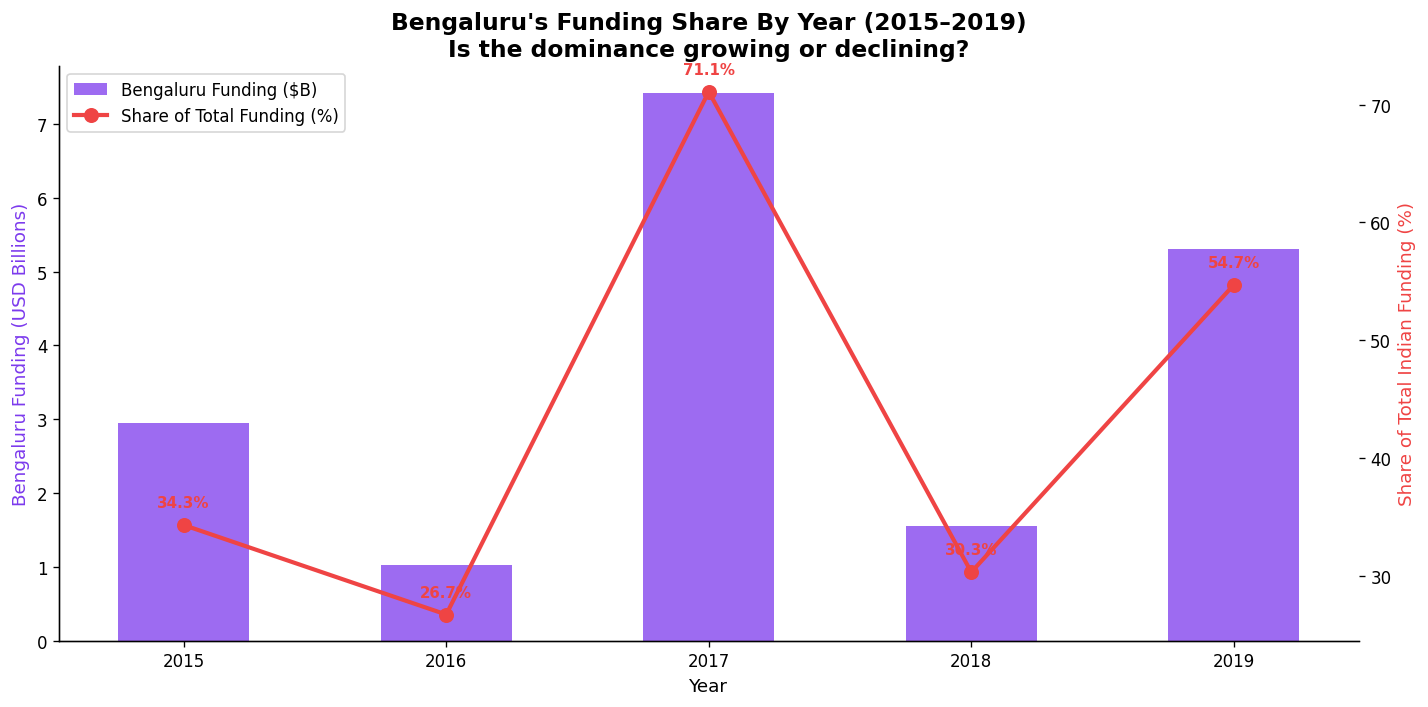

Chart 11 saved


In [17]:
# Chart 11: Bengaluru Funding Share By Year

blr = pd.read_sql("""
    WITH yearly_total AS (
        SELECT
            CAST(year AS INTEGER) AS year,
            SUM(amount_usd) AS total
        FROM funding_rounds
        WHERE year >= 2015 AND year <= 2019
          AND amount_usd IS NOT NULL
        GROUP BY year
    ),
    blr_total AS (
        SELECT
            CAST(year AS INTEGER) AS year,
            SUM(amount_usd) AS blr_funding
        FROM funding_rounds
        WHERE year >= 2015 AND year <= 2019
          AND city_clean = 'Bengaluru'
          AND amount_usd IS NOT NULL
        GROUP BY year
    )
    SELECT
        y.year,
        ROUND(b.blr_funding/1e9, 2) AS blr_bn,
        ROUND(b.blr_funding * 100.0 / y.total, 1) AS blr_share_pct
    FROM yearly_total y
    JOIN blr_total b ON y.year = b.year
    ORDER BY y.year
""", conn)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(blr['year'], blr['blr_bn'],
        color=COLORS['highlight'], alpha=0.75,
        width=0.5, label='Bengaluru Funding ($B)')

ax2 = ax1.twinx()
ax2.plot(blr['year'], blr['blr_share_pct'],
         color=COLORS['negative'], marker='o',
         linewidth=2.5, markersize=8,
         label='Share of Total Funding (%)')

for x, y in zip(blr['year'], blr['blr_share_pct']):
    ax2.text(x, y + 1.5, f'{y}%',
             ha='center', fontsize=9,
             fontweight='bold', color=COLORS['negative'])

ax1.set_xlabel('Year')
ax1.set_ylabel('Bengaluru Funding (USD Billions)',
               color=COLORS['highlight'])
ax2.set_ylabel('Share of Total Indian Funding (%)',
               color=COLORS['negative'])
ax1.set_title("Bengaluru's Funding Share By Year (2015–2019)\nIs the dominance growing or declining?")
ax1.set_xticks(blr['year'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left')

plt.tight_layout()
plt.savefig('../reports/figures/chart_11_bengaluru_share.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 11 saved")

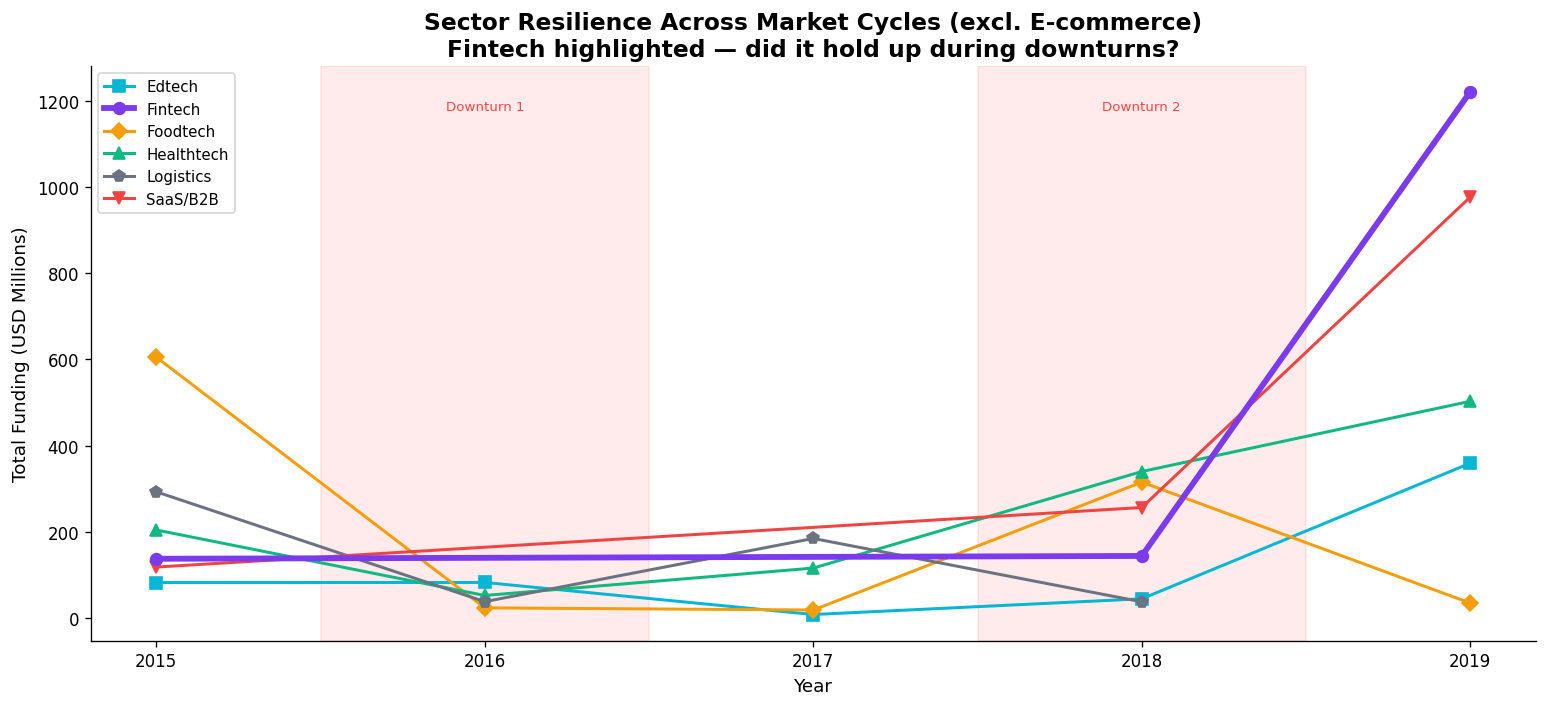

Chart 12 saved


In [19]:
# Chart 12: Fintech Resilience 

resilience = pd.read_sql("""
    WITH sector_phase AS (
        SELECT
            sector,
            CAST(year AS INTEGER) AS year,
            ROUND(SUM(amount_usd)/1e6, 1) AS funding_mn
        FROM funding_rounds
        WHERE year BETWEEN 2015 AND 2019
          AND sector IN ('Fintech','Edtech','Healthtech',
                         'Foodtech','Logistics','SaaS/B2B')
          AND amount_usd IS NOT NULL
        GROUP BY sector, year
    )
    SELECT * FROM sector_phase
    ORDER BY sector, year
""", conn)

fig, ax = plt.subplots(figsize=(13, 6))

sector_styles = {
    'Fintech':    {'color': COLORS['highlight'], 'lw': 3.5,
                   'marker': 'o', 'zorder': 5},
    'Edtech':     {'color': '#06B6D4', 'lw': 1.8,
                   'marker': 's', 'zorder': 3},
    'Healthtech': {'color': '#10B981', 'lw': 1.8,
                   'marker': '^', 'zorder': 3},
    'Foodtech':   {'color': '#F59E0B', 'lw': 1.8,
                   'marker': 'D', 'zorder': 3},
    'SaaS/B2B':   {'color': '#EF4444', 'lw': 1.8,
                   'marker': 'v', 'zorder': 3},
    'Logistics':  {'color': '#6B7280', 'lw': 1.8,
                   'marker': 'p', 'zorder': 3},
}

for sector, group in resilience.groupby('sector'):
    style = sector_styles.get(sector, {})
    ax.plot(group['year'], group['funding_mn'],
            label=sector,
            color=style.get('color', 'gray'),
            linewidth=style.get('lw', 1.5),
            marker=style.get('marker', 'o'),
            markersize=7,
            zorder=style.get('zorder', 2))

ax.axvspan(2015.5, 2016.5, alpha=0.08, color='red')
ax.axvspan(2017.5, 2018.5, alpha=0.08, color='red')
ax.text(2016, ax.get_ylim()[1] * 0.92,
        'Downturn 1', ha='center', fontsize=8,
        color='red', alpha=0.7)
ax.text(2018, ax.get_ylim()[1] * 0.92,
        'Downturn 2', ha='center', fontsize=8,
        color='red', alpha=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('Total Funding (USD Millions)')
ax.set_title('Sector Resilience Across Market Cycles (excl. E-commerce)\nFintech highlighted — did it hold up during downturns?')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks([2015, 2016, 2017, 2018, 2019])

plt.tight_layout()
plt.savefig('../reports/figures/chart_12_fintech_resilience.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 12 saved")

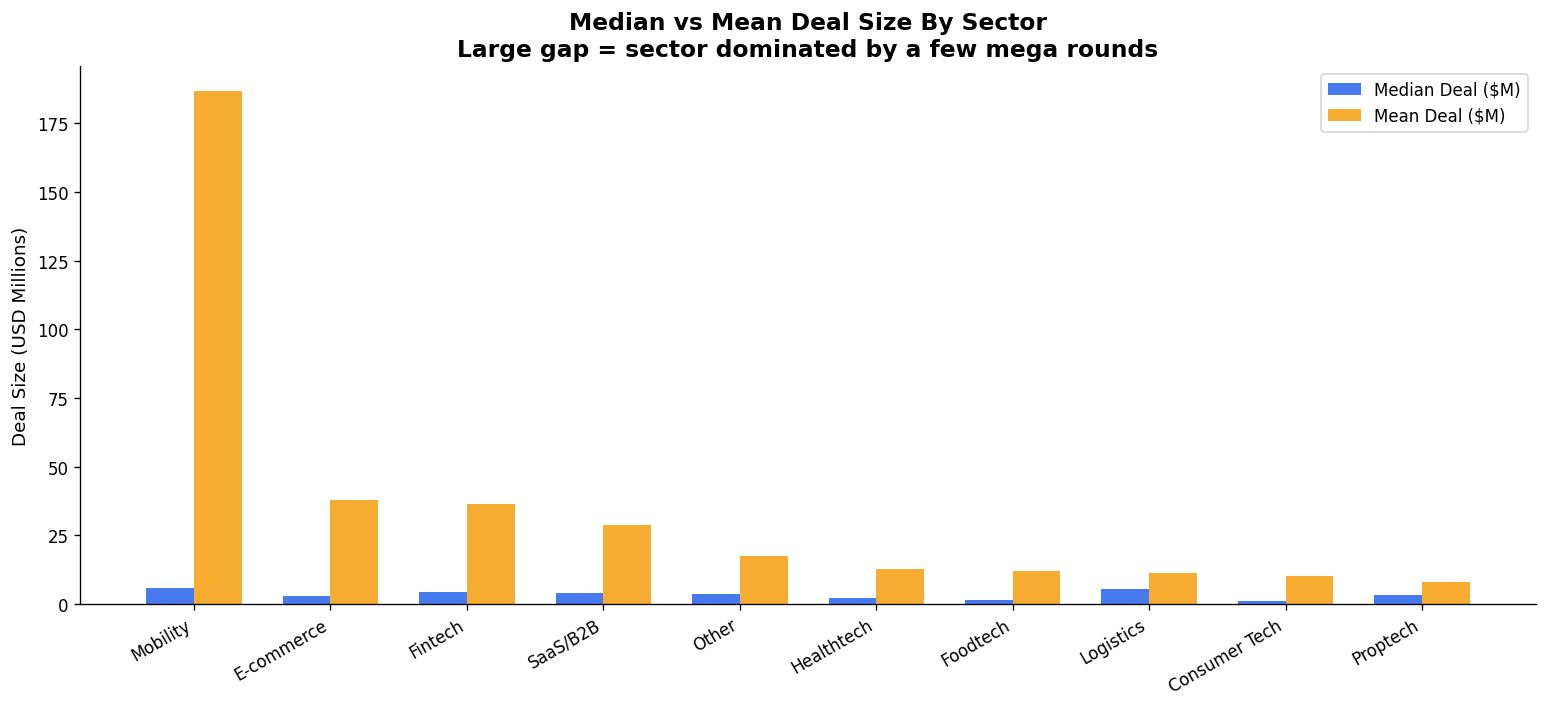

Chart 13 saved


In [20]:
# Chart 13: Median vs Mean Deal Size By Sector

median_mean = pd.read_sql("""
    WITH sector_stats AS (
        SELECT
            sector,
            amount_usd,
            ROW_NUMBER() OVER (
                PARTITION BY sector ORDER BY amount_usd
            ) AS rn,
            COUNT(*) OVER (PARTITION BY sector) AS cnt
        FROM funding_rounds
        WHERE sector IS NOT NULL
          AND amount_usd IS NOT NULL
          AND year >= 2014 AND year <= 2019
    ),
    medians AS (
        SELECT sector, AVG(amount_usd) AS median_usd
        FROM sector_stats
        WHERE rn IN ((cnt+1)/2, (cnt+2)/2)
        GROUP BY sector
    ),
    means AS (
        SELECT sector,
               ROUND(AVG(amount_usd)/1e6, 2) AS mean_mn,
               COUNT(*) AS deals
        FROM funding_rounds
        WHERE sector IS NOT NULL
          AND amount_usd IS NOT NULL
          AND year >= 2014 AND year <= 2019
        GROUP BY sector
    )
    SELECT m.sector, m.deals,
           ROUND(md.median_usd/1e6, 2) AS median_mn,
           m.mean_mn
    FROM means m
    JOIN medians md ON m.sector = md.sector
    ORDER BY m.mean_mn DESC
    LIMIT 10
""", conn)

x = np.arange(len(median_mean))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, median_mean['median_mn'],
               width, label='Median Deal ($M)',
               color=COLORS['primary'], alpha=0.85)
bars2 = ax.bar(x + width/2, median_mean['mean_mn'],
               width, label='Mean Deal ($M)',
               color=COLORS['secondary'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(median_mean['sector'], rotation=30, ha='right')
ax.set_ylabel('Deal Size (USD Millions)')
ax.set_title('Median vs Mean Deal Size By Sector\nLarge gap = sector dominated by a few mega rounds')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/chart_13_median_vs_mean.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 13 saved")

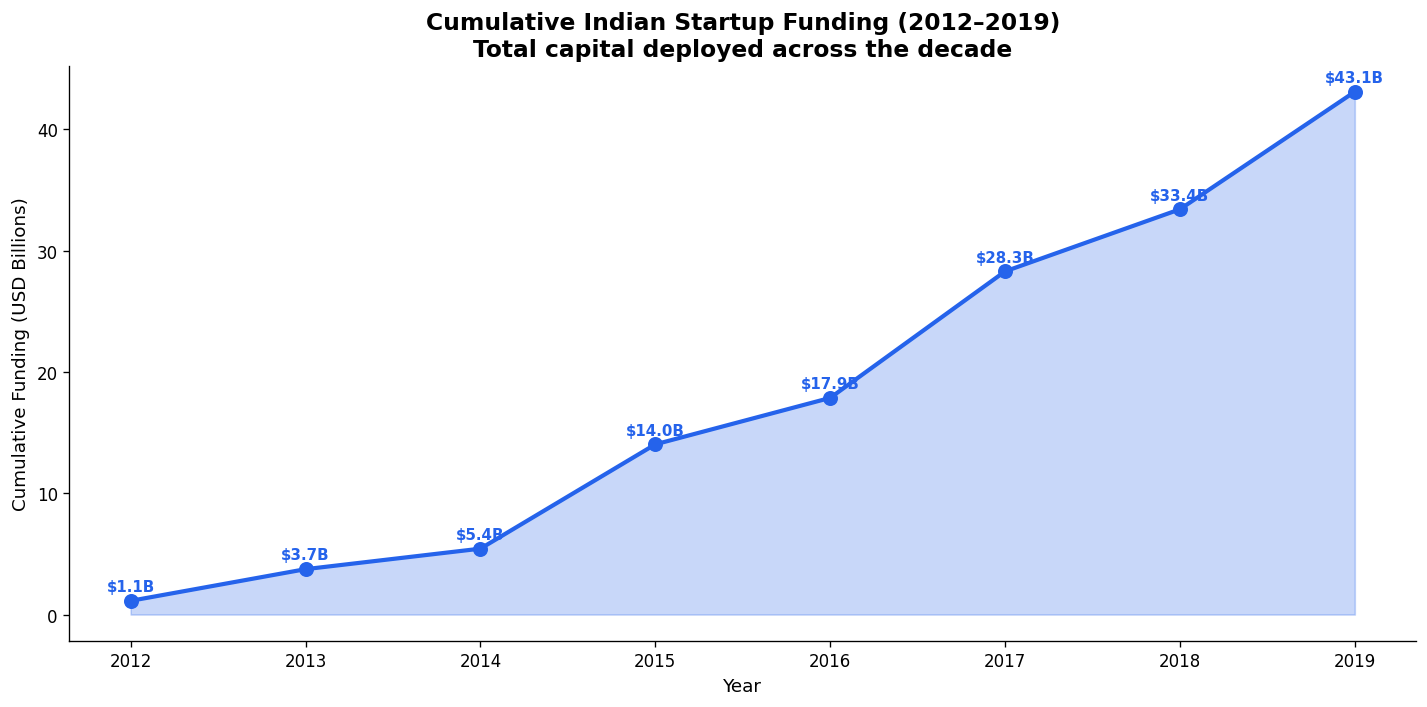

Chart 14 saved

All 14 charts complete.


In [21]:
# Chart 14: Cumulative Funding Growth

cumulative = pd.read_sql("""
    WITH yearly AS (
        SELECT
            CAST(year AS INTEGER) AS year,
            ROUND(SUM(amount_usd)/1e9, 2) AS funding_bn
        FROM funding_rounds
        WHERE year >= 2012 AND year <= 2019
          AND amount_usd IS NOT NULL
        GROUP BY year
    )
    SELECT
        year,
        funding_bn,
        ROUND(SUM(funding_bn) OVER (ORDER BY year), 2) AS cumulative_bn
    FROM yearly
    ORDER BY year
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(cumulative['year'],
                cumulative['cumulative_bn'],
                alpha=0.25, color=COLORS['primary'])
ax.plot(cumulative['year'],
        cumulative['cumulative_bn'],
        color=COLORS['primary'],
        linewidth=2.5, marker='o', markersize=8)

for x, y in zip(cumulative['year'], cumulative['cumulative_bn']):
    ax.text(x, y + 0.8, f'${y:.1f}B',
            ha='center', fontsize=9, fontweight='bold',
            color=COLORS['primary'])

ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Funding (USD Billions)')
ax.set_title('Cumulative Indian Startup Funding (2012–2019)\nTotal capital deployed across the decade')
ax.set_xticks(cumulative['year'])

plt.tight_layout()
plt.savefig('../reports/figures/chart_14_cumulative.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 14 saved")
print("\nAll 14 charts complete.")

---

## Part 2: Hypothesis Testing

Five commonly held narratives about the Indian startup ecosystem tested against data.

For each hypothesis:
- The claim is stated clearly
- The relevant data is presented
- A verdict is given: Confirmed / Nuanced / Debunked

---

### Hypothesis 1 — "Fintech is the most resilient sector across downturns"

**Claim:** Fintech maintains or grows its funding even during market downturns, outperforming other sectors.

**Data (from SQL Query 13):**

| Phase | Fintech | Foodtech | Edtech | Healthtech |
|---|---|---|---|---|
| Boom 2015 | $137.6M | $605.4M | $82.5M | $204.4M |
| Downturn 2016 | No data | $23.7M | $82.6M | $52.4M |
| Recovery 2017 | No data | $18.7M | $8.2M | $116.0M |
| Downturn 2018 | $144.1M | $315.4M | $44.7M | $340.0M |
| Late 2019 | $1,221.2M | $34.7M | $359.4M | $503.0M |

**Key finding:** Fintech's 2018 downturn funding ($144.1M) exceeded its 2015 boom funding ($137.6M). Every other sector shrank significantly during downturns. Fintech also showed the highest growth trajectory — from $137.6M in 2015 to $1.2B in 2019 (8.9x growth).

**Verdict: Confirmed.** Fintech is the only sector that grew during a downturn. Its funding trajectory was consistently upward regardless of market conditions — showing genuine structural demand, not hype-driven investment.

---

### Hypothesis 2 — "Bengaluru's dominance is declining"

**Claim:** As the Indian startup ecosystem matures, other cities are catching up and Bengaluru's share of funding is falling.

**Data (from SQL Query 12 and Chart 11):**

| Year | Bengaluru Share |
|---|---|
| 2015 | 34.3% |
| 2016 | 26.7% |
| 2017 | 71.1% |
| 2018 | 30.3% |
| 2019 | 54.7% |

**Key finding:** Bengaluru's share fluctuates between 27% and 71% with no consistent directional trend. The spikes in 2017 and 2019 are driven by a handful of mega rounds (Flipkart $1.4B in 2017, Ola/Swiggy in 2019) headquartered in Bengaluru. In distributed years (2016, 2018), Mumbai and Delhi close the gap significantly.

**Verdict: Nuanced.** Bengaluru's dominance is not declining — it is volatile. The city's share is entirely determined by whether a Bengaluru-based company raised a mega round that year. In deal count (not funding amount), the gap between Bengaluru and other cities has been narrowing. The narrative of "decline" is premature.

---

### Hypothesis 3 — "The 2015-2016 boom was volume-driven, not value-driven"

**Claim:** The 2015-2016 period saw an explosion in deal count but not proportional growth in deal quality or size.

**Data (from SQL Query 1 and Query 4):**

| Year | Deals | Total Funding | Avg Deal Size | YoY Change |
|---|---|---|---|---|
| 2014 | 191 | $1.7B | $8.9M | — |
| 2015 | 642 | $8.6B | $13.4M | +408% funding |
| 2016 | 586 | $3.8B | $6.5M | -55% funding |
| 2017 | 456 | $10.4B | $22.9M | +172% funding |

**Key finding:** In 2016, deal count stayed high (586 vs 642 in 2015) but total funding dropped 55% and average deal size fell from $13.4M to $6.5M. The market was flooded with small seed rounds. Meanwhile 2017 had fewer deals but 3.5x larger average sizes — showing the quality investors returned while the hype faded.

**Verdict: Confirmed.** 2015 was genuinely strong — both volume and value grew. 2016 was a volume bubble — deal count held but deal quality collapsed. The 2016 cohort's 13.3% follow-on rate (vs 2015's 26.1%) confirms that most 2016-funded companies were never viable.

---

### Hypothesis 4 — "The funding winter was a gradual grind, not a sudden crash"

**Claim:** The 2016-2019 funding decline happened slowly across many quarters rather than in one sharp correction.

**Data (from SQL Query 15):**

| Period | Deals | QoQ Change |
|---|---|---|
| 2015-Q3 | 188 | Peak |
| 2015-Q4 | 175 | -6.9% |
| 2016-Q1 | 166 | -5.1% |
| 2016-Q2 | 144 | -13.3% |
| 2016-Q3 | 140 | -2.8% |
| 2016-Q4 | 136 | -2.9% |
| 2017-Q1 | 124 | -8.8% |
| 2017-Q3 | 89 | -33.6% |
| 2018-Q4 | 30 | -54.5% |
| 2019-Q1 | 5 | -83.3% |

**Key finding:** From 2015-Q3 to 2019-Q1 there were 12 consecutive quarters of negative or near-zero QoQ deal count growth. No single quarter saw a crash — the decline was persistent and gradual, accelerating only in 2018-Q4 and 2019-Q1 when the bottom finally fell out.

**Verdict: Confirmed.** The funding winter was a 3-year grind from late 2015 through early 2019. This is structurally different from a crash — it was a slow, sustained correction as capital became more disciplined quarter by quarter. The market didn't panic; it sobered up.

---

### Hypothesis 5 — "The 2016 boom created companies that never raised follow-on funding"

**Claim:** The flood of 2016 seed rounds funded companies that weren't viable — most raised once and disappeared.

**Data (from SQL Query 14 and Chart 9):**

| Cohort Year | Companies | Raised Follow-on | Follow-on Rate |
|---|---|---|---|
| 2013 | 158 | 24 | 15.2% |
| 2014 | 161 | 35 | 21.7% |
| 2015 | 804 | 210 | 26.1% |
| 2016 | 767 | 102 | 13.3% |
| 2017 | 455 | 26 | 5.7% |
| 2018 | 186 | 5 | 2.7% |

**Key finding:** The 2015 cohort — the largest ever at 804 companies — had the highest follow-on rate at 26.1%. The 2016 cohort was almost as large (767 companies) but had nearly half the follow-on rate at 13.3%. 657 companies raised their first round in 2016 and never raised again.

**Verdict: Confirmed — and this is the strongest finding in the entire project.** The data shows that 2016 funded quantity, not quality. The funding winter didn't destroy good companies — it exposed that most 2016 companies were never good enough to raise again. The ecosystem didn't shrink; it was corrected.

---

## Hypothesis Testing — Summary Verdicts

| # | Hypothesis | Verdict | Key Number |
|---|---|---|---|
| 1 | Fintech is the most resilient sector | Confirmed | Only sector where downturn funding exceeded boom funding |
| 2 | Bengaluru's dominance is declining | Nuanced | Share fluctuates 27%–71% driven by mega rounds, not trending down |
| 3 | 2015-2016 boom was volume-driven | Confirmed | 2016 avg deal size fell to $6.5M despite 586 deals |
| 4 | Funding winter was a gradual grind | Confirmed | 12 consecutive quarters of negative QoQ deal growth |
| 5 | 2016 companies never raised follow-on | Confirmed | 13.3% follow-on rate vs 26.1% for 2015 cohort |

## Key Non-Obvious Insights

1. **The real boom was 2015, not 2016.** 2016 had more deals but worse outcomes.
2. **Fintech grew during downturns** — the only sector with structural rather than hype-driven demand.
3. **34 mega rounds ($200M+) captured 49% of all capital** — the power law is extreme.
4. **Bengaluru's dominance is a function of which companies raised mega rounds that year**, not a structural trend.
5. **The 2019 ecosystem was healthier than 2015** — fewer deals but all 6 funding stages represented for the first time.